In [19]:
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=3, suppress=True)


def softmax_rows(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


def softmax_1d(z):
    e = np.exp(z - np.max(z))
    return e / e.sum()

In [20]:
def quick_train_embeddings_and_predictor(vocab, embed_dim=6, hidden_dim=24):
    """
    Train small embeddings and a next-token predictor. Training iterations reduced for demo speed.
    """
    np.random.seed(42)
    word_to_id = {w: i for i, w in enumerate(vocab)}
    vocab_size = len(vocab)

    pairs = [(vocab[i], vocab[(i+1) % vocab_size]) for i in range(vocab_size)]
    X_ids = np.array([word_to_id[a] for a, _ in pairs])
    Y_ids = np.array([word_to_id[b] for _, b in pairs])

    Embedding = np.random.randn(vocab_size, embed_dim) * 0.5
    W1 = np.random.randn(embed_dim, hidden_dim) * 0.5
    b1 = np.zeros(hidden_dim)
    W2 = np.random.randn(hidden_dim, vocab_size) * 0.5
    b2 = np.zeros(vocab_size)

    lr = 0.5
    # use fewer iterations for quick demo
    for _ in range(1000):
        emb = Embedding[X_ids]
        a1 = np.tanh(emb @ W1 + b1)
        probs = softmax_rows(a1 @ W2 + b2)
        n = len(Y_ids)
        dz2 = probs.copy(); dz2[np.arange(n), Y_ids] -= 1; dz2 /= n
        dW2 = a1.T @ dz2; db2 = dz2.sum(0)
        dz1 = (dz2 @ W2.T) * (1 - a1**2)
        dW1 = emb.T @ dz1; db1 = dz1.sum(0)
        demb = dz1 @ W1.T
        dEmb = np.zeros_like(Embedding); np.add.at(dEmb, X_ids, demb)
        Embedding -= lr * dEmb; W1 -= lr * dW1; b1 -= lr * db1; W2 -= lr * dW2; b2 -= lr * db2

    return word_to_id, Embedding, W1, b1, W2, b2

In [ ]:
# Note: for interpretability, each head here is a hand-built 1-D category detector, not a learned Q @ K.T dot-product head. This illustrates what multi-head attention produces; it is not trained attention.
def build_category_keys(embedding, vocab, category_sets, head_count, logit_scale=4.0):
    """Build demonstration heads that respond to different token categories."""
    embedding_pinv = np.linalg.pinv(embedding)
    key_heads, query_heads, value_heads = [], [], []
    value_map = np.eye(embedding.shape[1])
    query_target = np.ones((len(vocab), 1))

    for category in category_sets[:head_count]:
        target = np.array([
            1.0 if word in category else 0.0 for word in vocab
        ]).reshape(-1, 1)
        key_projection = (embedding_pinv @ target) * logit_scale
        query_projection = (embedding_pinv @ query_target) * logit_scale
        key_heads.append(key_projection)
        query_heads.append(query_projection)
        value_heads.append(value_map)

    return query_heads, key_heads, value_heads

In [22]:
def attend_multi_head(x, query_heads, key_heads, value_heads, output_projection):
    """Apply all heads to the last-token query and combine their contexts."""
    head_contexts = []
    head_weights = []

    for query_projection, key_projection, value_projection in zip(
        query_heads, key_heads, value_heads
    ):
        queries = x @ query_projection
        keys = x @ key_projection
        values = x @ value_projection
        scores = queries[-1, 0] * keys[:, 0]
        weights = softmax_1d(scores)
        head_weights.append(weights)
        head_contexts.append(weights @ values)

    combined = np.concatenate(head_contexts)
    projected_context = combined @ output_projection
    return head_weights, head_contexts, projected_context

In [16]:
def compare_attention_patterns(all_head_weights):
    """Return pairwise cosine similarity between heads across all sequences."""
    flattened = np.array([
        np.concatenate([
            sequence_weights[head] for sequence_weights in all_head_weights
        ])
        for head in range(len(all_head_weights[0]))
    ])
    norms = np.linalg.norm(flattened, axis=1, keepdims=True)
    return (flattened @ flattened.T) / (norms @ norms.T + 1e-12)


def explain_head_patterns(sequences, all_head_weights, head_names):
    """Report tokens receiving the highest average weight from each head."""
    explanations = []
    for head, head_name in enumerate(head_names):
        token_weights = {}
        for sequence, sequence_weights in zip(sequences, all_head_weights):
            for token, weight in zip(sequence, sequence_weights[head]):
                token_weights.setdefault(token, []).append(float(weight))

        averages = {
            token: np.mean(weights) for token, weights in token_weights.items()
        }
        top_tokens = sorted(
            averages.items(), key=lambda item: item[1], reverse=True
        )[:3]
        summary = ", ".join(
            f"{token} ({weight * 100:.1f}%)" for token, weight in top_tokens
        )
        explanations.append(f"{head_name} appears to emphasize: {summary}")
    return explanations


def plot_attention_heatmaps(sequences, all_head_weights, head_names):
    """Display one labeled attention heatmap per sequence."""
    figure, axes = plt.subplots(
        len(sequences), 1, figsize=(10, 8), squeeze=False, constrained_layout=True
    )

    for row, (sequence, sequence_weights) in enumerate(
        zip(sequences, all_head_weights)
    ):
        axis = axes[row, 0]
        image = axis.imshow(
            np.array(sequence_weights), cmap="viridis", vmin=0, vmax=1
        )
        axis.set_xticks(
            range(len(sequence)), labels=sequence, rotation=25, ha="right"
        )
        axis.set_yticks(range(len(head_names)), labels=head_names)
        axis.set_title("Query: " + sequence[-1])

        for head in range(len(head_names)):
            for token in range(len(sequence)):
                weight = sequence_weights[head][token]
                axis.text(
                    token,
                    head,
                    f"{weight:.2f}",
                    ha="center",
                    va="center",
                    color="white" if weight < 0.55 else "black",
                )

    figure.colorbar(
        image, ax=axes[:, 0], label="Attention weight", shrink=0.8, pad=0.08
    )
    figure.suptitle("Week 4: Attention Patterns by Head", fontweight="bold")
    plt.show()

In [ ]:
def demo():
    vocab = [
        "Order", "Shipment", "Receive", "Restock", "Inventory",
        "Invoice", "Forecast", "Scenario", "Return", "Cancel",
    ]
    word_to_id, embedding, w1, b1, w2, b2 = (
        quick_train_embeddings_and_predictor(
            vocab, embed_dim=6, hidden_dim=24
        )
    )

    sequences = [
        ["Order", "Shipment", "Receive", "Restock", "Inventory"],
        ["Shipment", "Receive", "Restock", "Inventory", "Forecast"],
        ["Inventory", "Forecast", "Scenario", "Order", "Shipment"],
    ]
    category_sets = [
        {"Order", "Invoice", "Cancel"},
        {"Shipment", "Receive", "Return"},
        {"Restock", "Inventory", "Forecast"},
    ]
    head_names = ["Order/Invoice/Cancel head", "Shipment/Receive/Return head", "Restock/Inventory/Forecast head"]
    head_count = len(head_names)

    query_heads, key_heads, value_heads = build_category_keys(
        embedding, vocab, category_sets, head_count
    )
    output_projection = np.random.randn(
        head_count * embedding.shape[1], embedding.shape[1]
    ) * 0.5

    all_head_weights = []
    print(f"Multi-head attention demo with {head_count} heads.\n")

    for sequence in sequences:
        x = embedding[[word_to_id[word] for word in sequence]]
        head_weights, _, context = attend_multi_head(
            x, query_heads, key_heads, value_heads, output_projection
        )
        all_head_weights.append(head_weights)

        print("Sequence:", " -> ".join(sequence))
        for head_name, weights in zip(head_names, head_weights):
            formatted = ", ".join(
                f"{word}={weight:.1%}" for word, weight in zip(sequence, weights)
            )
            print(f"  {head_name}: {formatted}")

        hidden = np.tanh(context @ w1 + b1)
        probabilities = softmax_1d(hidden @ w2 + b2)
        top_predictions = np.argsort(probabilities)[::-1][:3]
        predictions = ", ".join(
            f"{vocab[index]}={probabilities[index]:.1%}"
            for index in top_predictions
        )
        print("  Top predictions:", predictions, "\n")
        # Note: Wo is random/untrained, so these predictions aren't meaningful. The point this week is the attention patterns, not the predicted next word.

    return sequences, all_head_weights, head_names

Multi-head attention demo with 3 heads.

Sequence: Order -> Shipment -> Receive -> Restock -> Inventory
  Order head: Order=13.1%, Shipment=16.5%, Receive=22.1%, Restock=30.3%, Inventory=18.0%
  Shipment head: Order=20.9%, Shipment=13.3%, Receive=11.7%, Restock=22.5%, Inventory=31.7%
  Inventory head: Order=35.1%, Shipment=28.0%, Receive=16.3%, Restock=8.9%, Inventory=11.8%
  Top predictions: Invoice=84.8%, Forecast=7.3%, Shipment=4.6% 

Sequence: Shipment -> Receive -> Restock -> Inventory -> Forecast
  Order head: Shipment=55.8%, Receive=8.8%, Restock=1.1%, Inventory=32.9%, Forecast=1.4%
  Shipment head: Shipment=26.3%, Receive=60.9%, Restock=0.9%, Inventory=0.1%, Forecast=11.8%
  Inventory head: Shipment=0.0%, Receive=1.5%, Restock=74.4%, Inventory=12.2%, Forecast=11.8%
  Top predictions: Forecast=57.9%, Invoice=17.9%, Scenario=9.7% 

Sequence: Inventory -> Forecast -> Scenario -> Order -> Shipment
  Order head: Inventory=20.1%, Forecast=17.5%, Scenario=19.7%, Order=22.0%, Shipment=

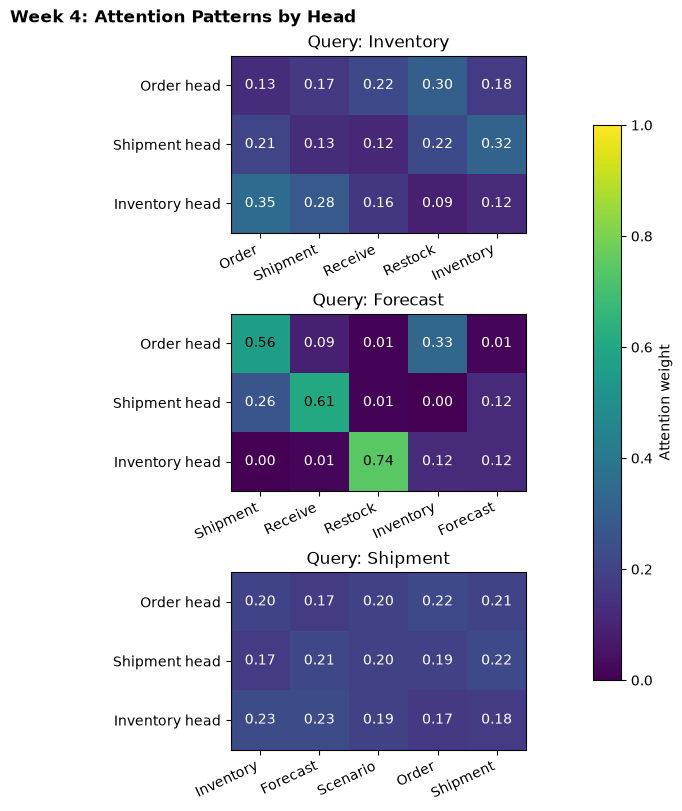

In [24]:
sequences, all_head_weights, head_names = demo()

similarity = compare_attention_patterns(all_head_weights)
print("Pairwise cosine similarity between attention patterns:")
print(" " * 18 + "  ".join(f"{name[:9]:>9s}" for name in head_names))
for name, row in zip(head_names, similarity):
    print(f"{name:17s} " + "  ".join(f"{value:9.3f}" for value in row))

print("\nObserved head behavior:")
for explanation in explain_head_patterns(
    sequences, all_head_weights, head_names
):
    print(" -", explanation)

print(
    "\nThese category roles were designed for demonstration; they were not "
    "learned end-to-end."
)

plot_attention_heatmaps(sequences, all_head_weights, head_names)